# Suffix Attribution Heatmap

Visualizes IG attribution for entire suffix predictions by reducing the 3D tensor `(features x prefix_steps x suffix_steps)` to 2D, showing only the **dominant feature** at each position.

**Note**: This shows only encoder (prefix) attributions. For encoder vs decoder split analysis, see `03_encoder_decoder_split.ipynb`. The decoder step attributions are computed with the encoder detached, making them incomparable to encoder attributions when shown side-by-side.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.domestic_declarations_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Cases: {len(eval_helper.cases)}, Suffix length: {model.seq_len_pred}")

Data set categories:  ([('Activity', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('s

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

# ENTER CASE NAME HERE

In [13]:
# Configuration
case_names = list(eval_helper.cases.keys())
CASE_NAME =  "declaration 102546" #case_names[0]
PREFIX_LENGTH = 3
TARGET = CONFIG.concept_name

print(f"Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}, Target: {TARGET}")

Case: declaration 102546, Prefix: 3, Target: Activity


In [ ]:
def get_case_prefix(case_name, prefix_len, eval_helper):
    full_case = eval_helper.cases[case_name]
    for pl, prefix, suffix in eval_helper._iterate_case(full_case):
        if pl == prefix_len:
            return prefix
    raise ValueError(f"Prefix length {prefix_len} not found")

def compute_suffix_attributions(tool, prefix, prefix_len, target, n_steps=50):
    """Compute IG attributions for all suffix steps.
    
    Note: Only encoder (prefix) attributions are shown. Decoder step attributions
    are computed with the encoder detached, making them incomparable.
    For encoder/decoder split analysis, see 03_encoder_decoder_split.ipynb.
    """
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results, feature_names, prefix_labels = [], None, None
    
    for suffix_step in range(tool.model.seq_len_pred):
        try:
            attr_map = tool.compute_attribution_map(
                process=process, prefix_length=prefix_len, target=target,
                target_class='auto', suffix_scope='step', suffix_step=suffix_step,
                method='integrated_gradients', n_steps=n_steps
            )
            if feature_names is None:
                feature_names, prefix_labels = attr_map.feature_names, attr_map.step_labels
            
            results.append((suffix_step, attr_map, attr_map.target_description))
            
            # Print with convergence delta
            delta = attr_map.convergence_delta if attr_map.convergence_delta else "N/A"
            print(f"  Step {suffix_step}: {attr_map.target_description}")
            print(f"           Positions: {len(attr_map.step_labels)}, Convergence delta: {delta}")
            
            if 'EOS' in attr_map.target_description:
                break
        except Exception as e:
            print(f"  Step {suffix_step} error: {e}")
            break
    
    return results, feature_names, prefix_labels

# Compute
prefix = get_case_prefix(CASE_NAME, PREFIX_LENGTH, eval_helper)
print("Computing attributions...")
results, feature_names, prefix_labels = compute_suffix_attributions(
    tool, prefix, PREFIX_LENGTH, TARGET, n_steps=CONFIG.ig_steps
)

In [15]:
def build_cube_and_reduce(results, feature_names, prefix_labels):
    """Build 3D cube and reduce to 2D by selecting top 2 features.
    
    All suffix steps have the same prefix positions (no intermediate predictions).
    """
    n_features = len(feature_names)
    n_suffix = len(results)
    n_prefix = len(prefix_labels)
    
    cube = np.full((n_features, n_prefix, n_suffix), np.nan)
    suffix_labels = []
    
    for suffix_step, attr_map, pred_desc in results:
        suffix_labels.append(pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"Step {suffix_step}")
        
        for feat_idx, feat_name in enumerate(feature_names):
            if feat_name in attr_map.attributions:
                vals = attr_map.attributions[feat_name]
                vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else vals
                cube[feat_idx, :len(vals), suffix_step] = vals
    
    # Reduce: find top 2 features at each position
    magnitude_1st = np.full((n_prefix, n_suffix), np.nan)
    magnitude_2nd = np.full((n_prefix, n_suffix), np.nan)
    feature_name_1st = np.empty((n_prefix, n_suffix), dtype=object)
    feature_name_2nd = np.empty((n_prefix, n_suffix), dtype=object)
    
    for p in range(n_prefix):
        for s in range(n_suffix):
            if not np.all(np.isnan(cube[:, p, s])):
                abs_vals = np.abs(cube[:, p, s])
                sorted_idx = np.argsort(abs_vals)[::-1]  # Descending
                
                # First (dominant)
                feat_idx_1 = sorted_idx[0]
                magnitude_1st[p, s] = cube[feat_idx_1, p, s]
                feature_name_1st[p, s] = feature_names[feat_idx_1]
                
                # Second
                if len(sorted_idx) > 1:
                    feat_idx_2 = sorted_idx[1]
                    magnitude_2nd[p, s] = cube[feat_idx_2, p, s]
                    feature_name_2nd[p, s] = feature_names[feat_idx_2]
    
    return magnitude_1st, magnitude_2nd, feature_name_1st, feature_name_2nd, suffix_labels, prefix_labels, cube

mag_1st, mag_2nd, feat_1st, feat_2nd, suffix_labels, step_labels, cube = build_cube_and_reduce(results, feature_names, prefix_labels)
print(f"Cube: {cube.shape} -> Reduced: {mag_1st.shape}")
print(f"Step labels: {step_labels}")

Cube: (8, 3, 4) -> Reduced: (3, 4)
Step labels: ['Declaration SUBMITTED by EMPLOYEE', 'Declaration APPROVED by ADMINISTRATION', 'Declaration REJECTED by SUPERVISOR']


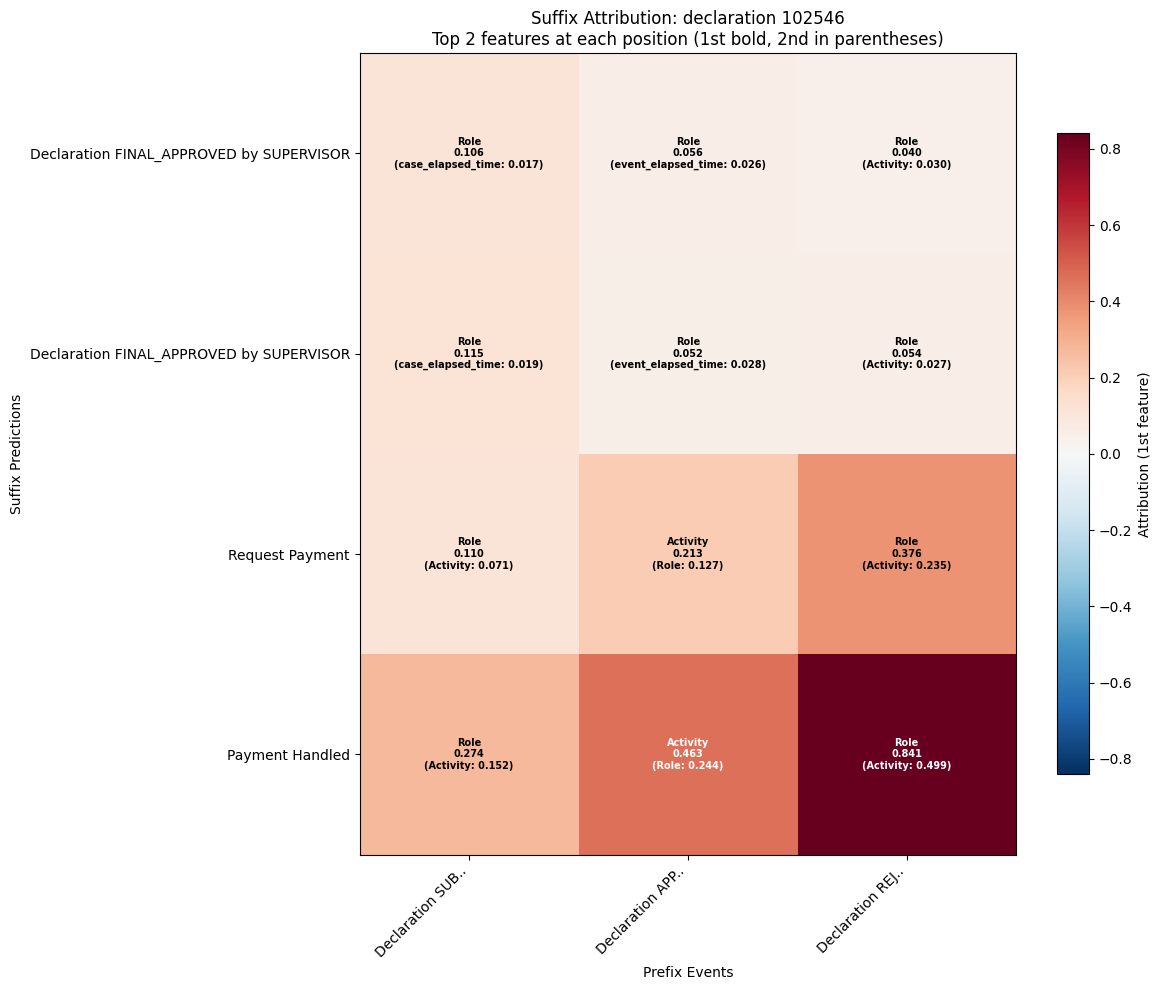

In [16]:
def plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, step_labels, suffix_labels, case_name):
    """Plot 2D heatmap showing top 2 features at each (prefix, suffix) position.
    
    Shows dominant feature (bold) and second feature (smaller) in each cell.
    """
    data = mag_1st.T
    n_suffix, n_positions = data.shape
    
    fig, ax = plt.subplots(figsize=(max(12, n_positions * 2.5), max(5, n_suffix * 2.5)))
    
    # Create masked array for proper NaN handling
    masked_data = np.ma.masked_invalid(data)
    
    vmax = max(np.nanmax(np.abs(data)), 0.001)
    
    # Plot heatmap with gray for NaN
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='lightgray')
    im = ax.imshow(masked_data, cmap=cmap, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
                   aspect='auto', interpolation='nearest')
    
    # Add cell annotations with top 2 features
    for i in range(n_suffix):
        for j in range(n_positions):
            if not np.isnan(data[i, j]):
                feat1 = feat_1st.T[i, j]
                val1 = mag_1st.T[i, j]
                feat2 = feat_2nd.T[i, j]
                val2 = mag_2nd.T[i, j]
                
                color = 'white' if abs(val1) > vmax * 0.5 else 'black'
                
                # First feature (bold, larger)
                text = f"{feat1}\n{val1:.3f}"
                # Second feature (smaller, below)
                if feat2 is not None and not np.isnan(val2):
                    text += f"\n({feat2}: {val2:.3f})"
                
                ax.text(j, i, text, ha='center', va='center',
                       color=color, fontsize=7, fontweight='bold')
    
    ax.set_xticks(range(n_positions))
    ax.set_xticklabels([l[:15] + '..' if len(l) > 15 else l for l in step_labels], rotation=45, ha='right')
    ax.set_yticks(range(n_suffix))
    ax.set_yticklabels(suffix_labels)
    ax.set_xlabel('Prefix Events')
    ax.set_ylabel('Suffix Predictions')
    ax.set_title(f'Suffix Attribution: {case_name}\nTop 2 features at each position (1st bold, 2nd in parentheses)')
    plt.colorbar(im, ax=ax, label='Attribution (1st feature)', shrink=0.8)
    ax.grid(False)
    plt.tight_layout()
    return fig

fig = plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, step_labels, suffix_labels, CASE_NAME)
plt.show()

In [17]:
# Summary with detailed attribution breakdown
print(f"\n{'─'*60}")
print(f"  SUMMARY: {CASE_NAME}")
print(f"{'─'*60}")

for s_idx, s_label in enumerate(suffix_labels):
    suffix_step, attr_map, pred_desc = results[s_idx]

    step_data = cube[:, :, s_idx]
    valid_mask = ~np.isnan(step_data[0, :])
    step_data_valid = step_data[:, valid_mask]

    print(f"\n  Suffix {s_idx}: {s_label}")
    print(f"  {'─'*40}")

    feat_totals = np.abs(step_data_valid).sum(axis=1)
    sorted_idx = np.argsort(feat_totals)[::-1]

    max_val = feat_totals[sorted_idx[0]] if len(sorted_idx) > 0 else 1

    for rank, idx in enumerate(sorted_idx[:5], 1):
        feat_name = feature_names[idx]
        total = feat_totals[idx]
        bar_len = int(20 * total / max_val) if max_val > 0 else 0
        bar = '█' * bar_len + '░' * (20 - bar_len)
        print(f"    {rank}. {feat_name:20s} {bar} {total:.3f}")

print(f"\n{'─'*60}")


────────────────────────────────────────────────────────────
  SUMMARY: declaration 102546
────────────────────────────────────────────────────────────

  Suffix 0: Declaration FINAL_APPROVED by SUPERVISOR
  ────────────────────────────────────────
    1. Role                 ████████████████████ 0.201
    2. Activity             ██████░░░░░░░░░░░░░░ 0.065
    3. case_elapsed_time    █████░░░░░░░░░░░░░░░ 0.059
    4. Resource             █████░░░░░░░░░░░░░░░ 0.051
    5. event_elapsed_time   ████░░░░░░░░░░░░░░░░ 0.045

  Suffix 1: Declaration FINAL_APPROVED by SUPERVISOR
  ────────────────────────────────────────
    1. Role                 ████████████████████ 0.222
    2. Activity             █████░░░░░░░░░░░░░░░ 0.066
    3. case_elapsed_time    █████░░░░░░░░░░░░░░░ 0.064
    4. Resource             ████░░░░░░░░░░░░░░░░ 0.048
    5. event_elapsed_time   ████░░░░░░░░░░░░░░░░ 0.048

  Suffix 2: Request Payment
  ────────────────────────────────────────
    1. Role                 ███